<a href="https://colab.research.google.com/github/adharsh-codes/aiml-assignment/blob/main/homeprice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("fedesoriano/the-boston-houseprice-data")

Using Colab cache for faster access to the 'the-boston-houseprice-data' dataset.


In [3]:
import pandas as pd

# The dataset is likely a CSV file within the downloaded directory
# Let's list the contents of the 'path' directory to find the CSV file
import os
print(os.listdir(path))

# Correcting the filename to 'boston.csv' based on the output of os.listdir(path)
df = pd.read_csv(os.path.join(path, 'boston.csv'))
display(df.head())

['boston.csv']


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


### Data Preparation for Model Training

First, I will separate the features (X) from the target variable (y). The target variable here is `MEDV`, which represents the median value of owner-occupied homes. All other columns will be considered features.

In [4]:
# Define features (X) and target (y)
X = df.drop('MEDV', axis=1)
y = df['MEDV']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (506, 13)
Target (y) shape: (506,)


Next, I will split the data into training and testing sets. This is a crucial step to evaluate the performance of our models on unseen data. I will use a 80/20 split, meaning 80% of the data will be used for training and 20% for testing.

In [5]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (404, 13)
X_test shape: (102, 13)
y_train shape: (404,)
y_test shape: (102,)


### Model Training and Evaluation

Now, I will train the specified regression models: Linear Regression, Decision Tree Regressor, and Random Forest Regressor. After training, I will evaluate their performance using common regression metrics such as Mean Squared Error (MSE), Mean Absolute Error (MAE), and R-squared.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize models
linear_model = LinearRegression()
decision_tree_model = DecisionTreeRegressor(random_state=42)
random_forest_model = RandomForestRegressor(random_state=42)

models = {
    'Linear Regression': linear_model,
    'Decision Tree Regressor': decision_tree_model,
    'Random Forest Regressor': random_forest_model
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

    print(f"{name} Performance:")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"  Mean Absolute Error (MAE): {mae:.2f}")
    print(f"  R-squared (R2): {r2:.2f}")

# Display all results in a DataFrame for easy comparison
results_df = pd.DataFrame(results).T
display(results_df)


Training Linear Regression...
Linear Regression Performance:
  Mean Squared Error (MSE): 24.29
  Root Mean Squared Error (RMSE): 4.93
  Mean Absolute Error (MAE): 3.19
  R-squared (R2): 0.67

Training Decision Tree Regressor...
Decision Tree Regressor Performance:
  Mean Squared Error (MSE): 10.42
  Root Mean Squared Error (RMSE): 3.23
  Mean Absolute Error (MAE): 2.39
  R-squared (R2): 0.86

Training Random Forest Regressor...
Random Forest Regressor Performance:
  Mean Squared Error (MSE): 7.90
  Root Mean Squared Error (RMSE): 2.81
  Mean Absolute Error (MAE): 2.04
  R-squared (R2): 0.89


,MSE,RMSE,MAE,R2
Linear Regression,24.291119,4.928602,3.189092,0.668759
Decision Tree Regressor,10.416078,3.227395,2.394118,0.857963
Random Forest Regressor,7.901514,2.810963,2.039539,0.892253


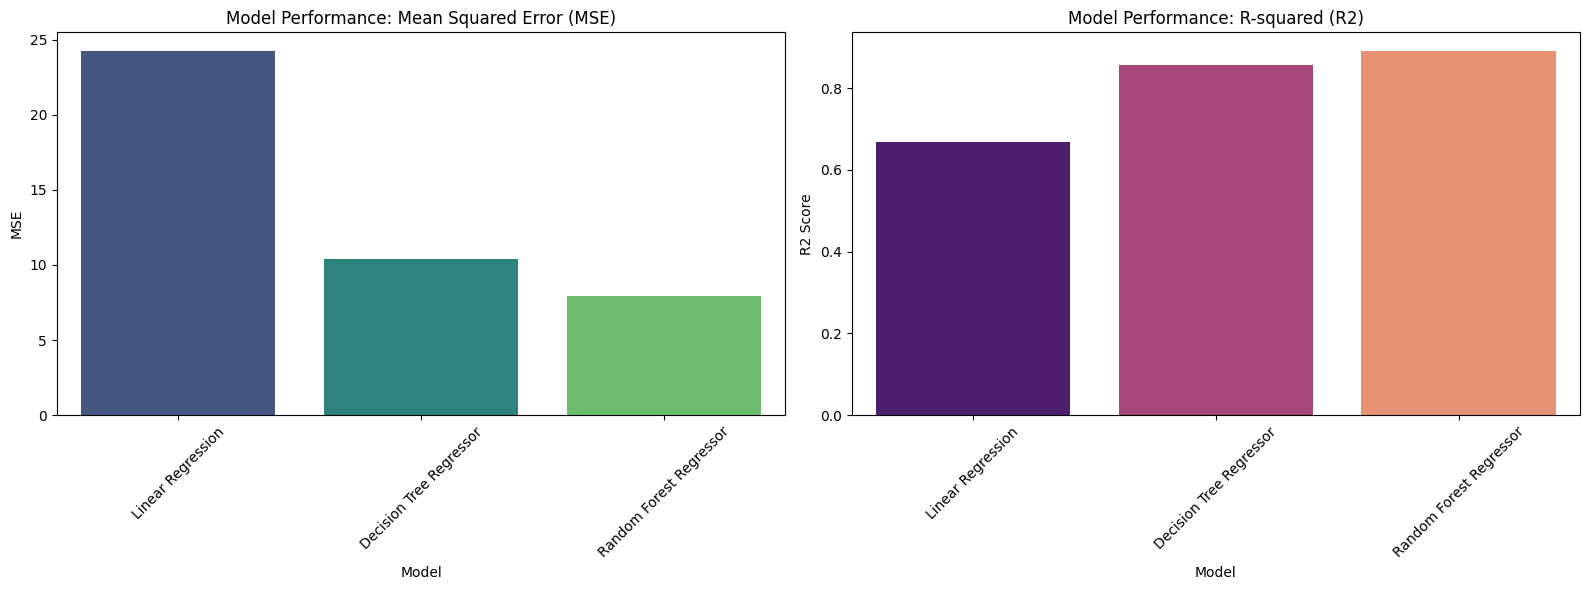

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots for MSE and R2
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot MSE
sns.barplot(x=results_df.index, y='MSE', data=results_df, ax=axes[0], palette='viridis', hue=results_df.index, legend=False)
axes[0].set_title('Model Performance: Mean Squared Error (MSE)')
axes[0].set_ylabel('MSE')
axes[0].set_xlabel('Model')
axes[0].tick_params(axis='x', rotation=45)

# Plot R2
sns.barplot(x=results_df.index, y='R2', data=results_df, ax=axes[1], palette='magma', hue=results_df.index, legend=False)
axes[1].set_title('Model Performance: R-squared (R2)')
axes[1].set_ylabel('R2 Score')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

This bar chart visually confirms that the Random Forest Regressor has the lowest MSE and the highest R2 score, indicating it is the most accurate model among the three for this dataset.